<a href="https://colab.research.google.com/github/etrunova89-stack/fake-news-classification/blob/main/fake_news_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --quiet transformers datasets scikit-learn pandas numpy matplotlib seaborn torch accelerate


In [ ]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Завантажуємо датасет
true_df  = pd.read_csv('True.csv')
fake_df  = pd.read_csv('Fake.csv')

# Додаємо мітки
true_df['label'] = 1   # правдиві
fake_df['label'] = 0   # фейкові

print(f'Правдивих статей: {len(true_df):,}')
print(f'Фейкових статей:  {len(fake_df):,}')
print(f'Колонки: {true_df.columns.tolist()}')

Правдивих статей: 21,417
Фейкових статей:  23,481
Колонки: ['title', 'text', 'subject', 'date', 'label']


In [ ]:
# Об'єднуємо та перемішуємо
df = pd.concat([true_df, fake_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Загальний розмір: {len(df):,}')
print(f'Баланс класів:')
print(df['label'].value_counts())
df.head(3)

Загальний розмір: 44,898
Баланс класів:
label
0    23481
1    21417
Name: count, dtype: int64


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0


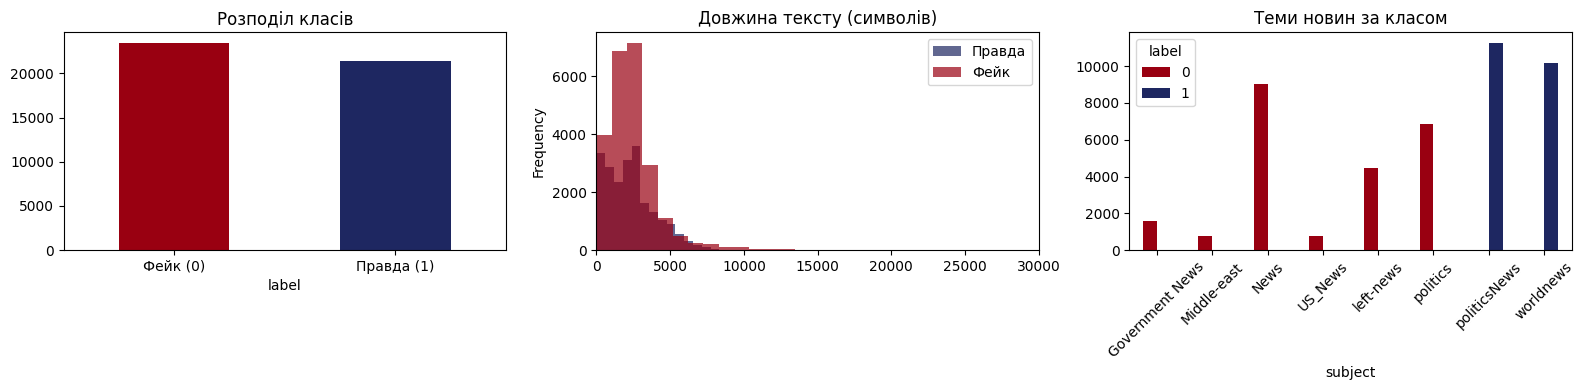

Середня довжина тексту:
  Правдиві: 2383 символів
  Фейкові:  2547 символів


In [ ]:
#2. EDA розвідувальний аналіз даних
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Розподіл класів
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#990011','#1E2761'])
axes[0].set_title('Розподіл класів')
axes[0].set_xticklabels(['Фейк (0)', 'Правда (1)'], rotation=0)

# Довжина тексту
df['text_len'] = df['text'].fillna('').apply(len)
df[df['label']==1]['text_len'].plot(kind='hist', bins=50, ax=axes[1], alpha=0.7, color='#1E2761', label='Правда')
df[df['label']==0]['text_len'].plot(kind='hist', bins=50, ax=axes[1], alpha=0.7, color='#990011', label='Фейк')
axes[1].set_title('Довжина тексту (символів)')
axes[1].legend()
axes[1].set_xlim(0, 30000)

# Теми
if 'subject' in df.columns:
    subject_counts = df.groupby(['subject','label']).size().unstack(fill_value=0)
    subject_counts.plot(kind='bar', ax=axes[2], color=['#990011','#1E2761'])
    axes[2].set_title('Теми новин за класом')
    axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Середня довжина тексту:\n  Правдиві: {df[df['label']==1]['text_len'].mean():.0f} символів")
print(f"  Фейкові:  {df[df['label']==0]['text_len'].mean():.0f} символів")


In [ ]:
# Перевірка data leakage
reuters_mask = df['text'].str.contains(r'\(Reuters\)', case=False, na=False)
print('Статті з маркером (Reuters):')
print(df[reuters_mask]['label'].value_counts())
print(f'\n% правдивих статей з (Reuters): {reuters_mask[df["label"]==1].mean()*100:.1f}%')
print(f'% фейкових статей з (Reuters):  {reuters_mask[df["label"]==0].mean()*100:.1f}%')

# Інші потенційні маркери які можуть винукнути
for pattern in ['21st Century Wire', 'DC Clothesline', 'infowars', 'breitbart']:
    mask = df['text'].str.contains(pattern, case=False, na=False)
    if mask.sum() > 0:
        print(f'\nМаркер "{pattern}": fake={mask[df["label"]==0].sum()}, real={mask[df["label"]==1].sum()}')


Статті з маркером (Reuters):
label
1    21247
0        9
Name: count, dtype: int64

% правдивих статей з (Reuters): 99.2%
% фейкових статей з (Reuters):  0.0%

Маркер "21st Century Wire": fake=1254, real=0

Маркер "DC Clothesline": fake=6, real=0

Маркер "infowars": fake=156, real=2

Маркер "breitbart": fake=1247, real=100


In [ ]:
#Препроцесинг

#Готуємо дві версії датасету:
#Версія A: з усім текстом з можливими варінтами лікенджу
#Версія B: з видаленими маркерами джерела
def clean_text(text: str) -> str:
    """Базове очищення тексту."""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def clean_text_no_leakage(text: str) -> str:
    text = clean_text(text)
    # Видаляємо х-ні маркери Reuters
    text = re.sub(r'\(Reuters\)\s*[-—]?', '', text, flags=re.IGNORECASE)
    text = re.sub(r'^[A-Z\s]+,?\s*\(Reuters\)', '', text)  # "WASHINGTON (Reuters)"
    text = re.sub(r'^[A-Z ]+\s*[-—]\s*', '', text)         # all-caps dateline
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Об'єднуємо заголовки та текст для кращого контексту
df['full_text']          = (df['title'].fillna('') + ' ' + df['text'].fillna('')).apply(clean_text)
df['full_text_no_leak']  = (df['title'].fillna('') + ' ' + df['text'].fillna('')).apply(clean_text_no_leakage)

# Видаляємо порожні тексти
df = df[df['full_text'].str.len() > 20].reset_index(drop=True)

print(f'Датасет після очищення: {len(df):,} рядків')
print('\nПриклад (з leakage):',   df['full_text'].iloc[0][:200])
print('\nПриклад (без leakage):', df['full_text_no_leak'].iloc[0][:200])


Датасет після очищення: 44,889 рядків

Приклад (з leakage): BREAKING: GOP Chairman Grassley Has Had Enough, DEMANDS Trump Jr. Testimony Donald Trump s White House is in chaos, and they are trying to cover it up. Their Russia problems are mounting by the hour, 

Приклад (без leakage): BREAKING: GOP Chairman Grassley Has Had Enough, DEMANDS Trump Jr. Testimony Donald Trump s White House is in chaos, and they are trying to cover it up. Their Russia problems are mounting by the hour, 


In [ ]:
#5. Розбиття на тренування, верифікування та тестування данних
from sklearn.model_selection import train_test_split

# 70% тренувальний, 15% верифікаціний та  15% для тестування
X = df['full_text'].values
X_nl = df['full_text_no_leak'].values
y = df['label'].values

X_train, X_temp, X_nl_train, X_nl_temp, y_train, y_temp = train_test_split(
    X, X_nl, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, X_nl_val, X_nl_test, y_val, y_test = train_test_split(
    X_temp, X_nl_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train:      {len(X_train):,} ({y_train.mean()*100:.1f}% real)')
print(f'Validation: {len(X_val):,} ({y_val.mean()*100:.1f}% real)')
print(f'Test:       {len(X_test):,} ({y_test.mean()*100:.1f}% real)')


Train:      31,422 (47.7% real)
Validation: 6,733 (47.7% real)
Test:       6,734 (47.7% real)


In [ ]:
# 6. Допоміжні функції для оцінки -  малюємо confusion matrix + ROC
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)


def evaluate_model(name: str, y_true, y_pred, y_proba=None) -> dict:
    """Рахує всі метрики і повертає словник"""
    metrics = {
        'model':     name,
        'accuracy':  round(accuracy_score(y_true, y_pred),    4),
        'precision': round(precision_score(y_true, y_pred),   4),
        'recall':    round(recall_score(y_true, y_pred),      4),
        'f1':        round(f1_score(y_true, y_pred),          4),
        'roc_auc':   round(roc_auc_score(y_true, y_proba), 4) if y_proba is not None else 'N/A',
    }
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(classification_report(y_true, y_pred, target_names=['Fake (0)','Real (1)']))
    print(f'  ROC-AUC:  {metrics["roc_auc"]}')
    return metrics


def plot_confusion_matrix(name: str, y_true, y_pred, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=11)
    ax.set_xlabel('Передбачено')
    ax.set_ylabel('Фактично')


all_results = []


In [ ]:
# 7. Baseline: TF-IDF + Logistic Regression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logreg_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        strip_accents='unicode',
        analyzer='word',
        token_pattern=r'\w{2,}',
        min_df=3,
    )),
    ('clf', LogisticRegression(
        C=1.0,
        solver='lbfgs',
        max_iter=1000,
        random_state=42,
    )),
])

print('Тренуємо TF-IDF + Logistic Regression')
logreg_pipeline.fit(X_train, y_train)

y_pred_lr  = logreg_pipeline.predict(X_test)
y_proba_lr = logreg_pipeline.predict_proba(X_test)[:, 1]

metrics_lr = evaluate_model('TF-IDF + LogReg', y_test, y_pred_lr, y_proba_lr)
all_results.append(metrics_lr)

Тренуємо TF-IDF + Logistic Regression

  TF-IDF + LogReg
              precision    recall  f1-score   support

    Fake (0)       1.00      1.00      1.00      3521
    Real (1)       0.99      1.00      0.99      3213

    accuracy                           1.00      6734
   macro avg       1.00      1.00      1.00      6734
weighted avg       1.00      1.00      1.00      6734

  ROC-AUC:  0.9996


In [ ]:
# 8. Baseline: TF-IDF + Linear SVM
import torch
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        strip_accents='unicode',
        analyzer='word',
        token_pattern=r'\w{2,}',
        min_df=3,
    )),
    ('clf', CalibratedClassifierCV(LinearSVC(C=0.5, random_state=42, max_iter=2000))),
])

print('Тренуємо TF-IDF + Linear SVM...')
svm_pipeline.fit(X_train, y_train)


Тренуємо TF-IDF + Linear SVM...


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, min_df=3,
                                 ngram_range=(1, 2), strip_accents='unicode',
                                 sublinear_tf=True, token_pattern='\\w{2,}')),
                ('clf',
                 CalibratedClassifierCV(estimator=LinearSVC(C=0.5,
                                                            max_iter=2000,
                                                            random_state=42)))])

In [ ]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
from torch.utils.data import Dataset

MODEL_NAME = 'bert-base-uncased'
MAX_LEN    = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True,
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item


print('Токенізуємо дані... (може зайняти 1-2 хвилини)')
train_dataset = NewsDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = NewsDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = NewsDataset(X_test,  y_test,  tokenizer, MAX_LEN)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Токенізуємо дані... (може зайняти 1-2 хвилини)
Train: 31422 | Val: 6733 | Test: 6734


In [ ]:
from sklearn.metrics import f1_score as sk_f1
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'f1':       sk_f1(labels, preds),
        'accuracy': (preds == labels).mean(),
    }


model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)

training_args = TrainingArguments(
    output_dir='./bert_results',
    num_train_epochs=3,
    per_device_train_batch_size=8,   # було 16
    per_device_eval_batch_size=16,   # було 32
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    fp16=True,
    report_to='none',
)

trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print('Починаємо fine-tuning BERT... (~20-30 хвилин на T4 GPU)')
trainer.train()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Починаємо fine-tuning BERT... (~20-30 хвилин на T4 GPU)


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.000026,0.001449,0.999844,0.999851
2,0.000021,0.001341,0.999844,0.999851
3,0.000005,0.001538,0.999844,0.999851


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=11784, training_loss=0.014372633184603566, metrics={'train_runtime': 1871.9584, 'train_samples_per_second': 50.357, 'train_steps_per_second': 6.295, 'total_flos': 1.240121337228288e+16, 'train_loss': 0.014372633184603566, 'epoch': 3.0})

In [ ]:
# Оцінка BERT на тестовій вибірці
import torch.nn.functional as F

bert_preds_raw = trainer.predict(test_dataset)
y_pred_bert  = np.argmax(bert_preds_raw.predictions, axis=1)
y_proba_bert = F.softmax(torch.tensor(bert_preds_raw.predictions), dim=1).numpy()[:, 1]

metrics_bert = evaluate_model('Fine-tuned BERT', y_test, y_pred_bert, y_proba_bert)
all_results.append(metrics_bert)


  Fine-tuned BERT
              precision    recall  f1-score   support

    Fake (0)       1.00      1.00      1.00      3521
    Real (1)       1.00      1.00      1.00      3213

    accuracy                           1.00      6734
   macro avg       1.00      1.00      1.00      6734
weighted avg       1.00      1.00      1.00      6734

  ROC-AUC:  1.0


In [ ]:
results_df = pd.DataFrame(all_results).set_index('model')

# фіксуємо дублікати в індексах
results_df = results_df[~results_df.index.duplicated(keep='first')]

print('\n=== ЗВЕДЕНІ РЕЗУЛЬТАТИ ===\n')
print(results_df.to_string())

results_df.reset_index().style\
    .background_gradient(cmap='Blues', subset=['accuracy','f1','roc_auc'])\
    .background_gradient(cmap='Reds',  subset=['recall'])\
    .format({'accuracy':'{:.4f}','precision':'{:.4f}',
             'recall':'{:.4f}','f1':'{:.4f}','roc_auc':'{:.4f}'})


=== ЗВЕДЕНІ РЕЗУЛЬТАТИ ===

                 accuracy  precision  recall      f1  roc_auc
model                                                        
TF-IDF + LogReg    0.9951     0.9947  0.9950  0.9949   0.9996
Fine-tuned BERT    0.9993     0.9997  0.9988  0.9992   1.0000


,model,accuracy,precision,recall,f1,roc_auc
0,TF-IDF + LogReg,0.9951,0.9947,0.9950,0.9949,0.9996
1,Fine-tuned BERT,0.9993,0.9997,0.9988,0.9992,1.0000


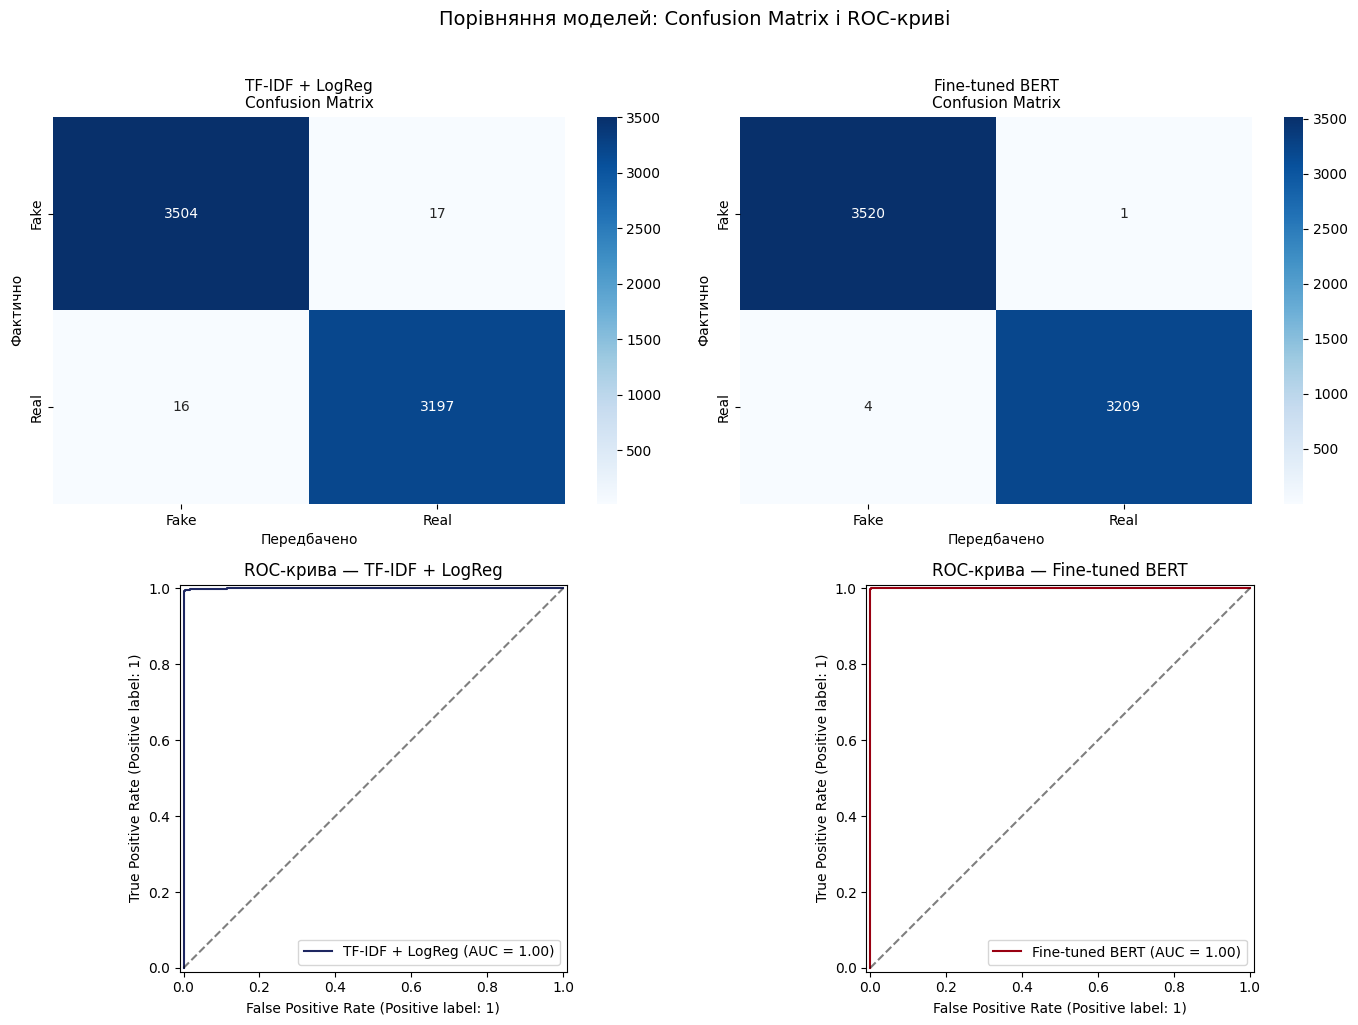

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # 2x2 замість 2x3

models_for_plot = [
    ('TF-IDF + LogReg',  y_pred_lr,   y_proba_lr),
    ('Fine-tuned BERT',  y_pred_bert, y_proba_bert),
]

# Confusion matrices по найвищому рядку
for i, (name, y_pred, _) in enumerate(models_for_plot):
    plot_confusion_matrix(name, y_test, y_pred, axes[0, i])

# ROC curves - нижній рядок
colors = ['#1E2761', '#990011']
for i, (name, _, y_proba) in enumerate(models_for_plot):
    RocCurveDisplay.from_predictions(
        y_test, y_proba, name=name, ax=axes[1, i], color=colors[i]
    )
    axes[1, i].set_title(f'ROC-крива — {name}')
    axes[1, i].plot([0,1],[0,1],'k--', alpha=0.5)

plt.suptitle('Порівняння моделей: Confusion Matrix і ROC-криві', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
 # 12. Аналіз помилок (FP / FN)
test_df = df.iloc[len(X_train)+len(X_val):].copy().reset_index(drop=True)
test_df = test_df.iloc[:len(y_test)].copy()
test_df['y_true']    = y_test
test_df['y_pred_lr'] = y_pred_lr


def error_type(row):
    if row['y_true'] == 1 and row['y_pred_lr'] == 0: return 'FN (пропущений фейк→правда)'
    if row['y_true'] == 0 and row['y_pred_lr'] == 1: return 'FP (блокована правда→фейк)'
    if row['y_true'] == row['y_pred_lr'] == 1:        return 'TP (правильно: правда)'
    return 'TN (правильно: фейк)'

test_df['error_type'] = test_df.apply(error_type, axis=1)

print('Розподіл помилок:')
print(test_df['error_type'].value_counts())


if 'subject' in test_df.columns:
    print('\nПомилки за тематикою:')
    errors = test_df[test_df['error_type'].str.startswith('F')]
    print(errors.groupby(['subject','error_type']).size().unstack(fill_value=0))

Розподіл помилок:
error_type
TN (правильно: фейк)           3504
TP (правильно: правда)         3197
FP (блокована правда→фейк)       17
FN (пропущений фейк→правда)      16
Name: count, dtype: int64

Помилки за тематикою:
error_type       FN (пропущений фейк→правда)  FP (блокована правда→фейк)
subject                                                                 
Government News                            0                           1
News                                       1                           5
left-news                                  0                           1
politics                                   2                           4
politicsNews                               9                           6
worldnews                                  4                           0


In [ ]:
#  деякі приклади FN
fn_examples = test_df[
    (test_df['y_true'] == 1) & (test_df['y_pred_lr'] == 0)
][['title','full_text']].head(3)

print('\n=== False Negatives (пропущені фейки — LogReg) ===')
for i, row in fn_examples.iterrows():
    print(f'\n[{i}] Title: {row["title"]}')
    print(f'     Text:  {row["full_text"][:200]}...')


=== False Negatives (пропущені фейки — LogReg) ===

[556] Title: British foreign minister arrives in U.S. to meet Trump advisers
     Text:  British foreign minister arrives in U.S. to meet Trump advisers LONDON (Reuters) - Britain’s foreign minister Boris Johnson has arrived in the United States to meet close advisers to President-elect D...

[652] Title: Russia media group that angered Kremlin is sold
     Text:  Russia media group that angered Kremlin is sold MOSCOW (Reuters) - A Russian media group which angered some in the Kremlin by reporting on the business interests of people close to President Vladimir ...

[842] Title: Zimbabwe cabinet pick to show if Mnangagwa is breaking with the past
     Text:  Zimbabwe cabinet pick to show if Mnangagwa is breaking with the past HARARE (Reuters) - New Zimbabwean President Emmerson Mnangagwa is expected to form a new cabinet this week, with all eyes on whethe...


In [ ]:
# дяякі приклади як FP що були заблоковані як фейк
fp_examples = test_df[
    (test_df['y_true'] == 0) & (test_df['y_pred_lr'] == 1)
][['title','full_text']].head(3)

print('\n=== False Positives (правдиві, хибно заблоковані — LogReg) ===')
for i, row in fp_examples.iterrows():
    print(f'\n[{i}] Title: {row["title"]}')
    print(f'     Text:  {row["full_text"][:200]}...')


=== False Positives (правдиві, хибно заблоковані — LogReg) ===

[258] Title: Kerry meets authors of dissenting cable on U.S. Syria policy
     Text:  Kerry meets authors of dissenting cable on U.S. Syria policy WASHINGTON (Reuters) - U.S. Secretary of State John Kerry met on Tuesday with about 10 of the 51 State Department officials who last week w...

[299] Title:  Donald Trump Vote Broke Up This Couple’s Marriage
     Text:  Donald Trump Vote Broke Up This Couple’s Marriage The 2016 election has been particularly hard on relationships. Social media is beginning to resemble a large echo chamber, with people with diverse vi...

[493] Title: WAS MICHELLE OBAMA In On Beyonce’s Cop-Hating Super Bowl Performance? [Video]
     Text:  WAS MICHELLE OBAMA In On Beyonce’s Cop-Hating Super Bowl Performance? [Video] In an interview that is a tradition before the Super Bowl, the Obamas sat down with Oprah s BFF Gayle King to chitty chat ...


In [ ]:
#13. Перевірка гіпотези Data Leakage

print('Тренуємо LogReg на тексті БЕЗ маркерів джерела')

logreg_nl = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000, ngram_range=(1, 2),
        sublinear_tf=True, min_df=3,
    )),
    ('clf', LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)),
])

logreg_nl.fit(X_nl_train, y_train)
y_pred_nl  = logreg_nl.predict(X_nl_test)
y_proba_nl = logreg_nl.predict_proba(X_nl_test)[:, 1]

metrics_nl = evaluate_model('TF-IDF + LogReg (no leakage)', y_test, y_pred_nl, y_proba_nl)
all_results.append(metrics_nl)

print('\n--- Порівняння: з маркерами vs без маркерів ---')
comp = pd.DataFrame([metrics_lr, metrics_nl]).set_index('model')
print(comp.to_string())

delta_f1 = metrics_lr['f1'] - metrics_nl['f1']
print(f'\nΔ F1 (with - without leakage markers): {delta_f1:+.4f}')
if delta_f1 > 0.01:
    print('✓ Data leakage підтверджено: маркери джерела значно впливали на результат.')
else:
    print('○ Leakage мінімальний: модель навчилась справжнім ознакам тексту.')

Тренуємо LogReg на тексті БЕЗ маркерів джерела

  TF-IDF + LogReg (no leakage)
              precision    recall  f1-score   support

    Fake (0)       0.99      0.99      0.99      3521
    Real (1)       0.99      0.99      0.99      3213

    accuracy                           0.99      6734
   macro avg       0.99      0.99      0.99      6734
weighted avg       0.99      0.99      0.99      6734

  ROC-AUC:  0.9989

--- Порівняння: з маркерами vs без маркерів ---
                              accuracy  precision  recall      f1  roc_auc
model                                                                     
TF-IDF + LogReg                 0.9951     0.9947   0.995  0.9949   0.9996
TF-IDF + LogReg (no leakage)    0.9892     0.9873   0.990  0.9887   0.9989

Δ F1 (with - without leakage markers): +0.0062
○ Leakage мінімальний: модель навчилась справжнім ознакам тексту.


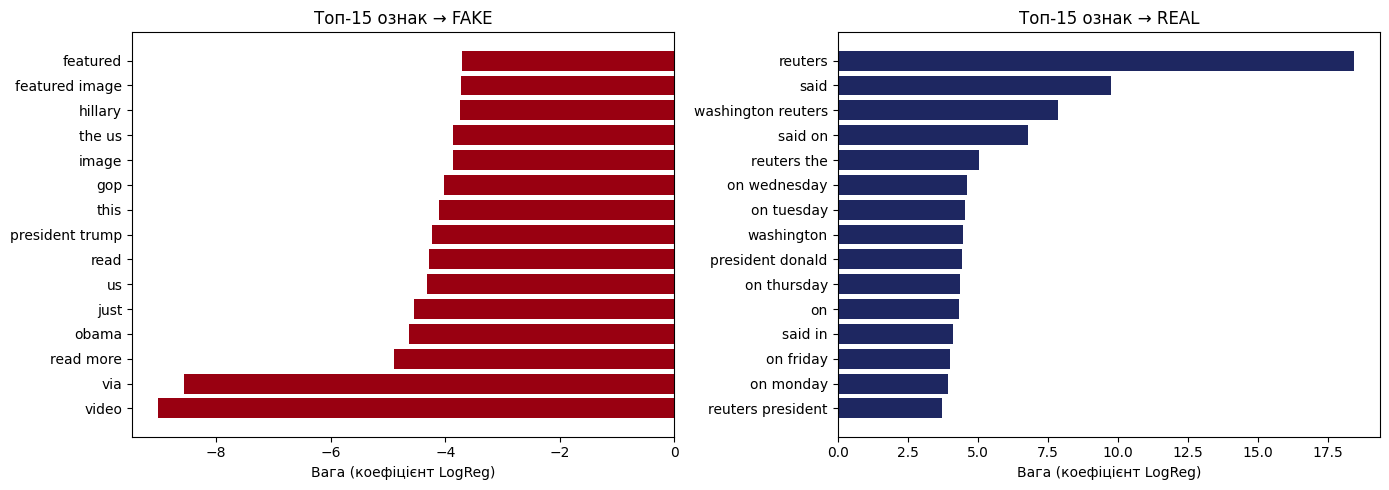

Топ слів для FAKE: ['video', 'via', 'read more', 'obama', 'just', 'us', 'read', 'president trump', 'this', 'gop', 'image', 'the us', 'hillary', 'featured image', 'featured']
Топ слів для REAL: ['reuters', 'said', 'washington reuters', 'said on', 'reuters the', 'on wednesday', 'on tuesday', 'washington', 'president donald', 'on thursday', 'on', 'said in', 'on friday', 'on monday', 'reuters president']


In [ ]:
# 14. Топ ознак по інтерпретації LogReg
tfidf_vec = logreg_pipeline.named_steps['tfidf']
clf_lr    = logreg_pipeline.named_steps['clf']

feature_names = np.array(tfidf_vec.get_feature_names_out())
coefs = clf_lr.coef_[0]

N = 15
top_fake = feature_names[np.argsort(coefs)[:N]]      # низькі ваги → фейк
top_real = feature_names[np.argsort(coefs)[-N:][::-1]]  # високі ваги → правда

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fake
axes[0].barh(range(N), sorted(coefs)[:N], color='#990011')
axes[0].set_yticks(range(N))
axes[0].set_yticklabels(top_fake)
axes[0].set_title('Топ-15 ознак → FAKE')
axes[0].set_xlabel('Вага (коефіцієнт LogReg)')

# Real
top_real_coefs = sorted(coefs)[-N:][::-1]
axes[1].barh(range(N), sorted(coefs)[-N:], color='#1E2761')
axes[1].set_yticks(range(N))
axes[1].set_yticklabels(top_real[::-1])
axes[1].set_title('Топ-15 ознак → REAL')
axes[1].set_xlabel('Вага (коефіцієнт LogReg)')

plt.tight_layout()
plt.savefig('top_features.png', dpi=120, bbox_inches='tight')
plt.show()

print('Топ слів для FAKE:', list(top_fake))
print('Топ слів для REAL:', list(top_real))


In [ ]:
#15. Фінальна зведена таблиця
final_df = pd.DataFrame(all_results).set_index('model')

print('\n' + '='*80)
print('  ФІНАЛЬНІ РЕЗУЛЬТАТИ — вставте в таблицю документа і презентації')
print('='*80)
print(final_df.to_string())
print('='*80)

# Зберігаємо в CSV
final_df.to_csv('final_results.csv')
print('\nЗбережено в final_results.csv')

# Скачуємо всі файли (лише якщо ноутбук запущено в Google Colab)
try:
    from google.colab import files
    for fname in ['final_results.csv', 'model_comparison.png', 'top_features.png', 'eda_plots.png']:
        try:
            files.download(fname)
        except Exception:
            print(f'(файл {fname} ще не існує або вже скачано)')
except ImportError:
    print('Не в Colab — файли залишаються локально в робочій директорії.')



  ФІНАЛЬНІ РЕЗУЛЬТАТИ — вставте в таблицю документа і презентації
                              accuracy  precision  recall      f1  roc_auc
model                                                                     
TF-IDF + LogReg                 0.9951     0.9947  0.9950  0.9949   0.9996
Fine-tuned BERT                 0.9993     0.9997  0.9988  0.9992   1.0000
TF-IDF + LogReg (no leakage)    0.9892     0.9873  0.9900  0.9887   0.9989

Збережено в final_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#16. Прогноз

def predict_all(text: str):
    clean = clean_text(text)
    print(f'Текст: "{clean[:100]}..."\n')

    # LogReg
    p_lr = logreg_pipeline.predict_proba([clean])[0]
    print(f'LogReg:  Fake={p_lr[0]:.3f}  Real={p_lr[1]:.3f}  → {"REAL" if p_lr[1]>0.5 else "FAKE"}')

    # SVM
    p_svm = svm_pipeline.predict_proba([clean])[0]
    print(f'SVM:     Fake={p_svm[0]:.3f}  Real={p_svm[1]:.3f}  → {"REAL" if p_svm[1]>0.5 else "FAKE"}')

    # BERT — переносимо тензори на той самий девайс що й модель
    device = next(model_bert.parameters()).device
    enc = tokenizer(
        clean, truncation=True, max_length=128,
        return_tensors='pt', padding=True
    )
    enc = {k: v.to(device) for k, v in enc.items()}  # ← фікс
    with torch.no_grad():
        logits = model_bert(**enc).logits
    probs = torch.softmax(logits, dim=1)[0].cpu()
    print(f'BERT:    Fake={probs[0]:.3f}  Real={probs[1]:.3f}  → {"REAL" if probs[1]>0.5 else "FAKE"}')


# Тест 1 на правдиву новину
predict_all("""
The Federal Reserve raised interest rates by 25 basis points on Wednesday,
as policymakers seek to bring inflation down to the 2% target while avoiding a recession.
""")

print()

# Тест 2  на фейк
predict_all("""
SHOCKING: Scientists ADMIT that vaccines contain microchips to track citizens!
The deep state globalists are using COVID as a cover to implement total surveillance.
Share this before it gets deleted!
""")

Текст: "The Federal Reserve raised interest rates by 25 basis points on Wednesday, as policymakers seek to b..."

LogReg:  Fake=0.278  Real=0.722  → REAL
SVM:     Fake=0.120  Real=0.880  → REAL
BERT:    Fake=1.000  Real=0.000  → FAKE

Текст: "SHOCKING: Scientists ADMIT that vaccines contain microchips to track citizens! The deep state global..."

LogReg:  Fake=0.912  Real=0.088  → FAKE
SVM:     Fake=0.999  Real=0.001  → FAKE
BERT:    Fake=1.000  Real=0.000  → FAKE
